# Model Evaluation And Renfinement


## Model Evaluation


+ In-sample evaluation tells us how well our model will fit the data used to train it 

(Đánh giá trong mẫu cho chúng ta biết được model có fit được với dữ liệu mà chúng ta đề ra hay không)

+ But what is the problem?
    
    + It doesn't tell us how well the trained model can be used to predict new data

    (Nó không cho chúng ta biết được ước tính một model đã train rồi thì sẽ có thể dùng để dự đoán các dữ liệu mới được không?)

+ Solution - What we are gonna slove it :

    + Split our data up - use the in-sample data or training data --> to train model 

        (Chia data ra thành 2 phần, trong đó 1 phần data dùng để train model)

    + The rest of the data, called test data --> is used as out-of sample data --> use to approximate how the model performs in the real world

        (Phần data còn lại, gọi là data thử nghiệm, dùng khi mà đã train model xong --> thử nghiệm - xem xét xem model sẽ hoạt động như thế nào so với thực tế)

+ **The sweet spot of sliptting data is 70% use to train - 30% use to test**

---

**When we have completed testing our model we should use all the data to train the model to get the best performance**

### Function to split the data:



##### Split data into random train and test subtest :


`from sklearn.model_selection import train_test_split`


**x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size = 0.3, random_state = 0)**

In that :

x_data is independent variables

y_data is dataset target: df['price']

x_train, y_train : parts of available data as training set

x_test, y_test : parts of available data as testing set

test_size : is a percentage of the data for the testing set 

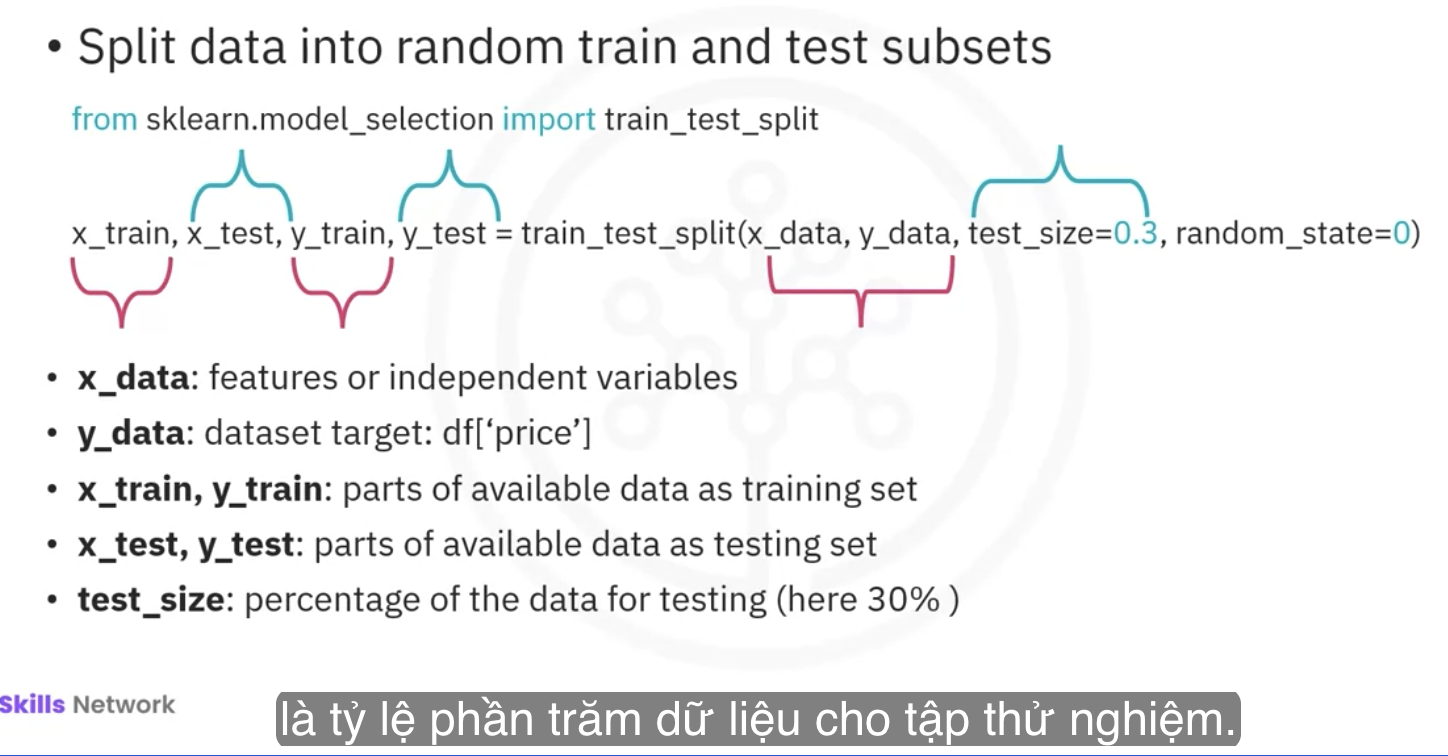

### Generalization performance

(Lỗi tổng quá hóa là thước đo mức độ dữ liệu của chúng ta dự đoán dữ liệu mà chưa từng thấy trước đây)

+ Generalization error is a measure of how well our data does at predicting previously unseen data

+ The error we obtain using our testing data is an approximation of this error

    (Sai số mà chúng ta tính được trên tập dữ liệu kiểm thử (testing data) là một ước lượng xấp xỉ cho sai số thực tế của mô hình)



### Cross validation 



+ Most common out-of-sample evaluation metrics

    (Các phương pháp/chỉ số đánh giá ngoài mẫu (out-of-sample) phổ biến nhất)

+ More effective use of data (each observation is used for both training and testing)

    (Sử dụng dữ liệu hiệu quả hơn (mỗi quan sát/điểm dữ liệu đều được sử dụng cho cả quá trình huấn luyện và kiểm thử))


### Function cross_val_score()

`from sklearn.model_selection import cross_val_score()`

`score = cross_val_score(lr, x_data, y_data, cv = 3)`

`np.mean(score)`

lr is the model we use to cross 

cv = 3=, means the data set is split into three equal partitions

# Cheat Sheet: Model Evaluation and Refinement

| Process | Description | Code Example |
| :--- | :--- | :--- |
| **Splitting data for training and testing** | The process involves first separating the target attribute from the rest of the data. Treat the target attribute as the output and the rest of the data as input. Now split the input and output datasets into training and testing subsets. | `from sklearn.model_selection import train_test_split`<br>`y_data = df['target_attribute']`<br>`x_data=df.drop('target_attribute',axis=1)`<br>`x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.10, random_state=1)` |
| **Cross validation score** | Without sufficient data, you go for cross validation, which involves creating different subsets of training and testing data multiple times and evaluating performance across all of them using the $R^2$ value. | `from sklearn.model_selection import cross_val_score`<br>`from sklearn.linear_model import LinearRegression`<br>`lre=LinearRegression()`<br>`Rcross = cross_val_score(lre,x_data[['attribute_1']],y_data,cv=n)`<br>`# n indicates number of times, or folds, for which the cross validation is to be done`<br>`Mean = Rcross.mean()`<br>`Std_dev = Rcross.std()` |
| **Cross validation prediction** | Use a cross validated model to create prediction of the output. | `from sklearn.model_selection import cross_val_predict`<br>`from sklearn.linear_model import LinearRegression`<br>`lre=LinearRegression()`<br>`yhat = cross_val_predict(lre,x_data[['attribute_1']], y_data,cv=4)` |
| **Ridge Regression and Prediction** | To create a better fitting polynomial regression model, like, one that avoids overfitting to the training data, we use the Ridge regression model with a parameter alpha that is used to modify the effect of higher-order parameters on the model prediction. | `from sklearn.linear_model import Ridge`<br>`pr=PolynomialFeatures(degree=2)`<br>`x_train_pr=pr.fit_transform(x_train[['attribute_1', 'attribute_2', ...]])`<br>`x_test_pr=pr.fit_transform(x_test[['attribute_1', 'attribute_2',...]])`<br>`RigeModel=Ridge(alpha=1)`<br>`RigeModel.fit(x_train_pr, y_train)`<br>`yhat = RigeModel.predict(x_test_pr)` |
| **Grid Search** | Use Grid Search to find the correct alpha value for which the Ridge regression model gives the best performance. It further uses cross-validation to create a more refined model. | `from sklearn.model_selection import GridSearchCV`<br>`from sklearn.linear_model import Ridge`<br>`parameters= [{'alpha': [0.001,0.1,1, 10, 100, 1000, 10000, ...]}]`<br>`RR=Ridge()`<br>`Grid1 = GridSearchCV(RR, parameters,cv=4)`<br>`Grid1.fit(x_data[['attribute_1', 'attribute_2', ...]], y_data)`<br>`BestRR=Grid1.best_estimator_`<br>`BestRR.score(x_test[['attribute_1', 'attribute_2', ...]], y_test)` |

# Giải Thích Chi Tiết : 


| Syntax / Hàm | Description (English) | Giải thích chi tiết (Tiếng Việt) |
| :--- | :--- | :--- |
| **`train_test_split(X, y, test_size, random_state)`** | Splits data into random train and test subsets. | Chia ngẫu nhiên bộ dữ liệu thành tập huấn luyện (train) và tập kiểm thử (test). `test_size=0.10` nghĩa là dành 10% dữ liệu để test. `random_state` giúp kết quả chia không đổi ở mỗi lần chạy. |
| **`cross_val_score(estimator, X, y, cv)`** | Evaluates a score by cross-validation. | Đánh giá mô hình bằng kỹ thuật xác thực chéo (cross-validation). Tập dữ liệu được chia thành `cv` phần (folds) để thay phiên nhau làm train/test, giúp đánh giá khách quan hơn so với chia 1 lần. |
| **`cross_val_predict(...)`** | Generates cross-validated estimates for each input data point. | Tạo ra các dự đoán cho từng điểm dữ liệu khi điểm đó nằm trong tập test của quá trình cross-validation. |
| **`Ridge(alpha)`** | Linear least squares with l2 regularization. | Mô hình Hồi quy tuyến tính có áp dụng chuẩn hóa L2 (Ridge) để phạt các trọng số lớn, giúp mô hình bớt phức tạp và tránh học vẹt (overfitting) dữ liệu train. Tham số $\alpha$ kiểm soát mức độ phạt. |
| **`GridSearchCV(estimator, param_grid, cv)`** | Exhaustive search over specified parameter values for an estimator. | Duyệt qua tất cả các tổ hợp siêu tham số trong từ điển `param_grid` để tìm ra cấu hình mô hình tốt nhất thông qua cross-validation. Cực kỳ hữu ích để tìm $\alpha$ tối ưu. |
| **`GridSearchCV.best_estimator_`**| Returns the estimator that was chosen by the search. | Thuộc tính trả về đối tượng mô hình hoàn chỉnh (đã được fit) mang lại hiệu suất cao nhất sau khi chạy tìm kiếm. |